# [Лекция 7. Matplotlib и введение в Numpy](https://colab.research.google.com/drive/1t0EKmuAK4MZhDsf4duaUIhuVWnJfOj9x)

## Основы библиотеки Matplotlib

При работе с данными очень важно их визуальное восприятие.

Библиотека Matplotlib предназначена для **визуализации данных**: построения диаграмм и графиков, в том числе трёхмерных.

Документация на английском языке по ней доступна онлайн на https://matplotlib.org/

Подключать библиотеку мы будем так:

In [ ]:
import matplotlib.pyplot as plt

### Диаграммы

В публицистике особенно любят **круговые диаграммы**. Они хорошо отображают *процентные соотношения*.

Например, на прошлом занятии была задача о выборах в студсовет. Давайте визуализируем результаты не текстом, а **круговой диаграммой**.

In [ ]:
from urllib.request import urlretrieve
urlretrieve("https://drive.google.com/uc?id=1j76WcAoQzA8Q8T5hTIKSx-vUqicMFoD3&export=download", "elections.txt")
urlretrieve("https://drive.google.com/uc?id=1HyhYpvFO2gYTtwVIProQJ-u74wz6h0aR&export=download", "students.txt")

('students.txt', <http.client.HTTPMessage at 0x7fb8a908c110>)

In [ ]:
from collections import Counter
with open("students.txt", encoding="utf8") as file:
    students_set = {line.strip() for line in file}
with open("elections.txt", encoding="utf8") as file:
    candidates_votes = Counter(line.strip() for line in file if line.strip() in students_set)
votes = [y for x, y in candidates_votes.most_common()]

Мы отделили список чисел с итоговыми результатами и можем просто подать его в функцию `plt.pie()`.

Для того, чтобы Jupyter не выводил лишний текст, добавим вызов функции `plt.show()`.

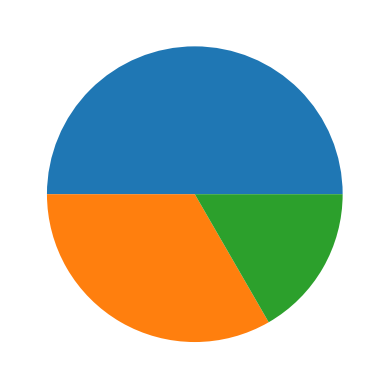

In [ ]:
plt.pie(votes)
plt.show()

Для того, чтобы диаграмма была более информативной, нужно добавить к секторам подписи. Это можно сделать через именованный параметр `labels`:

In [ ]:
candidates = [x for x, y in candidates_votes.most_common()]

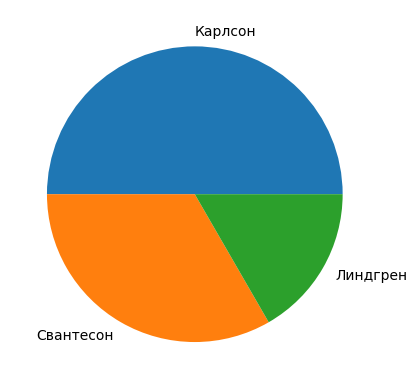

In [ ]:
plt.pie(votes, labels=candidates)
plt.show()

Для управления стилем диаграммы у функции `plt.pie()` есть множество дополнительных ключевых параметров:

1. `colors` — список цветов для каждого сектора,
2. `startangle` — начальный угол, от которого будут раскручиваться сектора,
3. `counterclock` — флажок, указывающий направление поворота,
4. `shadow` — флажок, указывающий, должна ли диаграмма отбрасывать тень,
5. `rotatelabels` — флажок, указывающий, что нужно поворачивать подписи к секторам.

И множество других, но мы остановимся на этих.

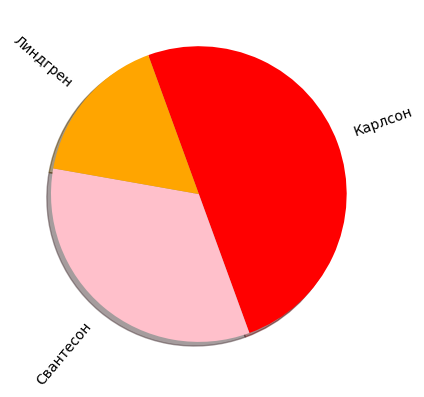

In [ ]:
plt.pie(votes, labels=candidates, colors=['red', 'pink', 'orange'], startangle=110,
        counterclock=False, shadow=True, rotatelabels=True)
plt.show()

### Столбчатые диаграммы

Можно визуализировать числовые данные в виде столбцов при помощи функции `plt.bar()`.
Естественно, у этой функции также много дополнительных управляющих параметров, которые вы сможете изучить в [документации Matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html).

Мы воспользуемся только `color`: укажем список цветов для каждого столбца.

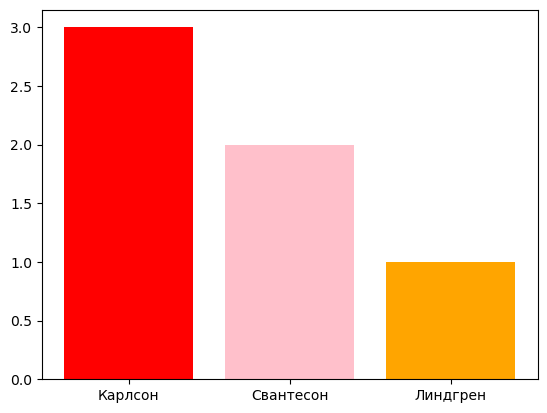

In [ ]:
plt.bar(candidates, votes, color=['red', 'pink', 'orange'])
plt.show()

В столбчатой диаграмме порядок столбцов часто не важен, и его выбирают исключительно из визуальных соображений.

Подобная диаграмма, но с горизонтально ориентированными столбцами создаётся функцией `barh`:

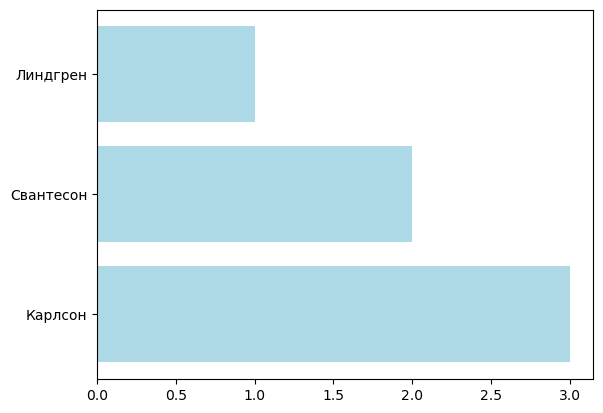

In [ ]:
plt.barh(candidates, votes, color='lightblue')
plt.show()

### Гистограммы

Для визуализации статистического распределения данных используется особая диаграмма — **гистограмма**.

Построим гистограмму своими руками.
Допустим, филолог хочет визуализировать зависимость количества слов от длины слова в тексте:

In [ ]:
text = """если я чешу в затылке не беда в голове моей опилки да да да и хотя там и опилки
но кричалки и вопилки а также сопелки пыхтелки сочиняю я неплохо иногда да
хорошо живёт на свете винни пух от того поёт он эти песни вслух и не важно чем он занят
если он худеть не станет а ведь он худеть не станет если конечно вовремя подкрепиться"""

Для каждой возможной длины слова нам нужно посчитать, сколько есть слов соответствующей длины.

In [ ]:
from collections import Counter

words_lengths_counter = Counter(len(word) for word in text.split())

Создадим список частот для всех возможных длин, включая нулевые частоты (количества).

In [ ]:
longest_word_length = max(words_lengths_counter)
histogram = [words_lengths_counter[word_length] for word_length in range(0, longest_word_length+1)]

Визуализируем эти частоты звёздочками через обычную функцию `print`:

In [ ]:
for k in range(longest_word_length, 0, -1):
    bin_width = histogram[k]
    print(str(k).ljust(4), "* " * bin_width)

12   * 
11   
10   
9    
8    * * 
7    * * * * * * * 
6    * * * * * * * * * 
5    * * * * * * * * 
4    * * * * * * * * * * 
3    * * * * 
2    * * * * * * * * * * * * * * * 
1    * * * * * * * * * * 


Звёздочки, воспринятые как горизонтальные "столбцы" (horizontal bars), дают визуальное представление о распределении частот длин слов.
В частности, что в данном тексте только одно по-настоящему длинное слово.

Сделаем визуализацию при помощи `barh`:

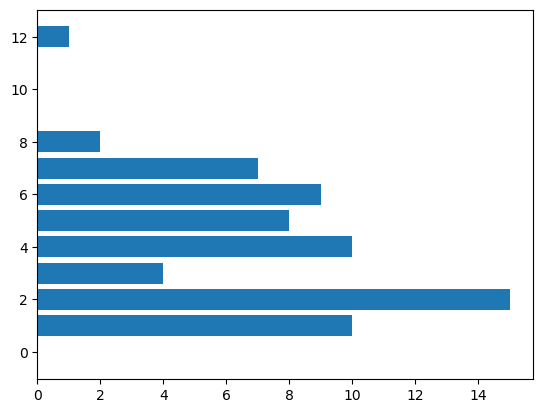

In [ ]:
plt.barh(range(0, longest_word_length + 1), histogram)
plt.show()

Вертикальное расположение будет более удобно для восприятия:

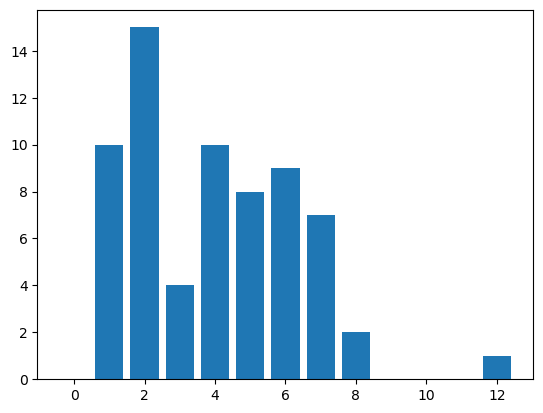

In [ ]:
plt.bar(range(0, longest_word_length + 1), histogram)
plt.show()

Итак, перед нами **гистограмма**.

Однако, статистический анализ нам пришлось выполнять вручную при помощи `Counter`, а задача визуализации распределения так типична, что для построения гистограмм есть специальная функция `hist()`:

In [ ]:
words_lengths = [len(word) for word in text.split()]

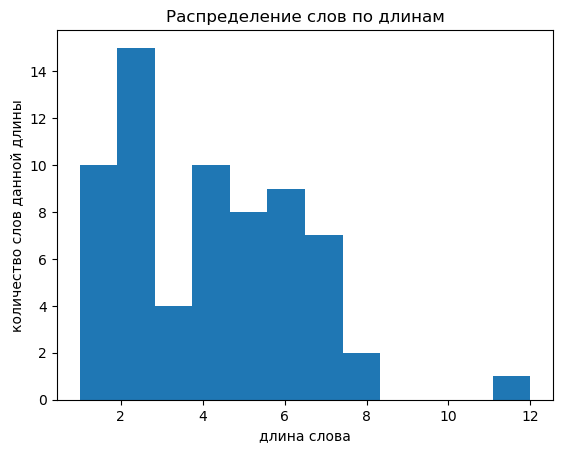

In [ ]:
plt.hist(words_lengths, bins=longest_word_length)
plt.title("Распределение слов по длинам")
plt.ylabel("количество слов данной длины")
plt.xlabel("длина слова")
plt.show()

Мы рассмотрели разные **диаграммы**, но, когда нам нужно отображать функциональную зависимость, мы используем **графики**.

### Прямоугольная система координат

Графики отображаются на так называемой *декартовой плоскости* — **прямоугольной системе координат**.

Положение точки на ней определяется двумя числами: координатами `x` и `y`.

### График функции

Если множество точек `(x, y)` отображает *функциональную зависимость* `y` от `x`, мы соединяем точки линией. И хотя значение функции в промежуточных точках даже не вычислялось, отрезки графика проходят примерно по ним, т.к. мы предполагаем *непрерывность функции*.

Используем функцию `plot()`:

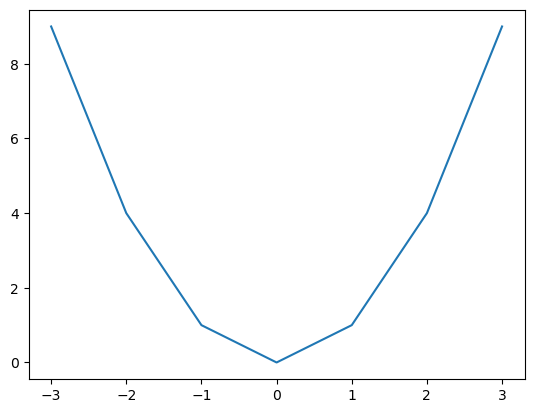

In [ ]:
x = [-3, -2, -1, 0, 1, 2, 3]
y = [9, 4, 1, 0, 1, 4, 9]
plt.plot(x, y)

### График разброса

Если между этими точками не предполагается функциональной зависимости, то их не надо соединять никакими линиями.

Множество точек можно отобразить при помощи функции `scatter()`:

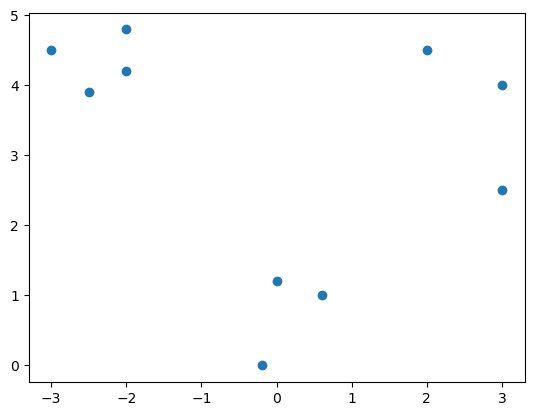

In [ ]:
x = [-3, -2.5, -2, +2, -0.2, 0, 0.6, -2, 3, 3]
y = [4.5, 3.9, 4.2, 4.5, 0, 1.2, 1, 4.8, 2.5, 4]
plt.scatter(x, y)

Заметим, что в этом случае для одного и того же `x` могло быть несколько `y`, а порядок точек по `x` мог быть произвольным.

## Математические функции

### Функция как отображение

В математике функция рассматривается как **однозначное отображение**, в котором каждому *прообразу* из области определения функции соответствует только один *образ* из множества значений функции.

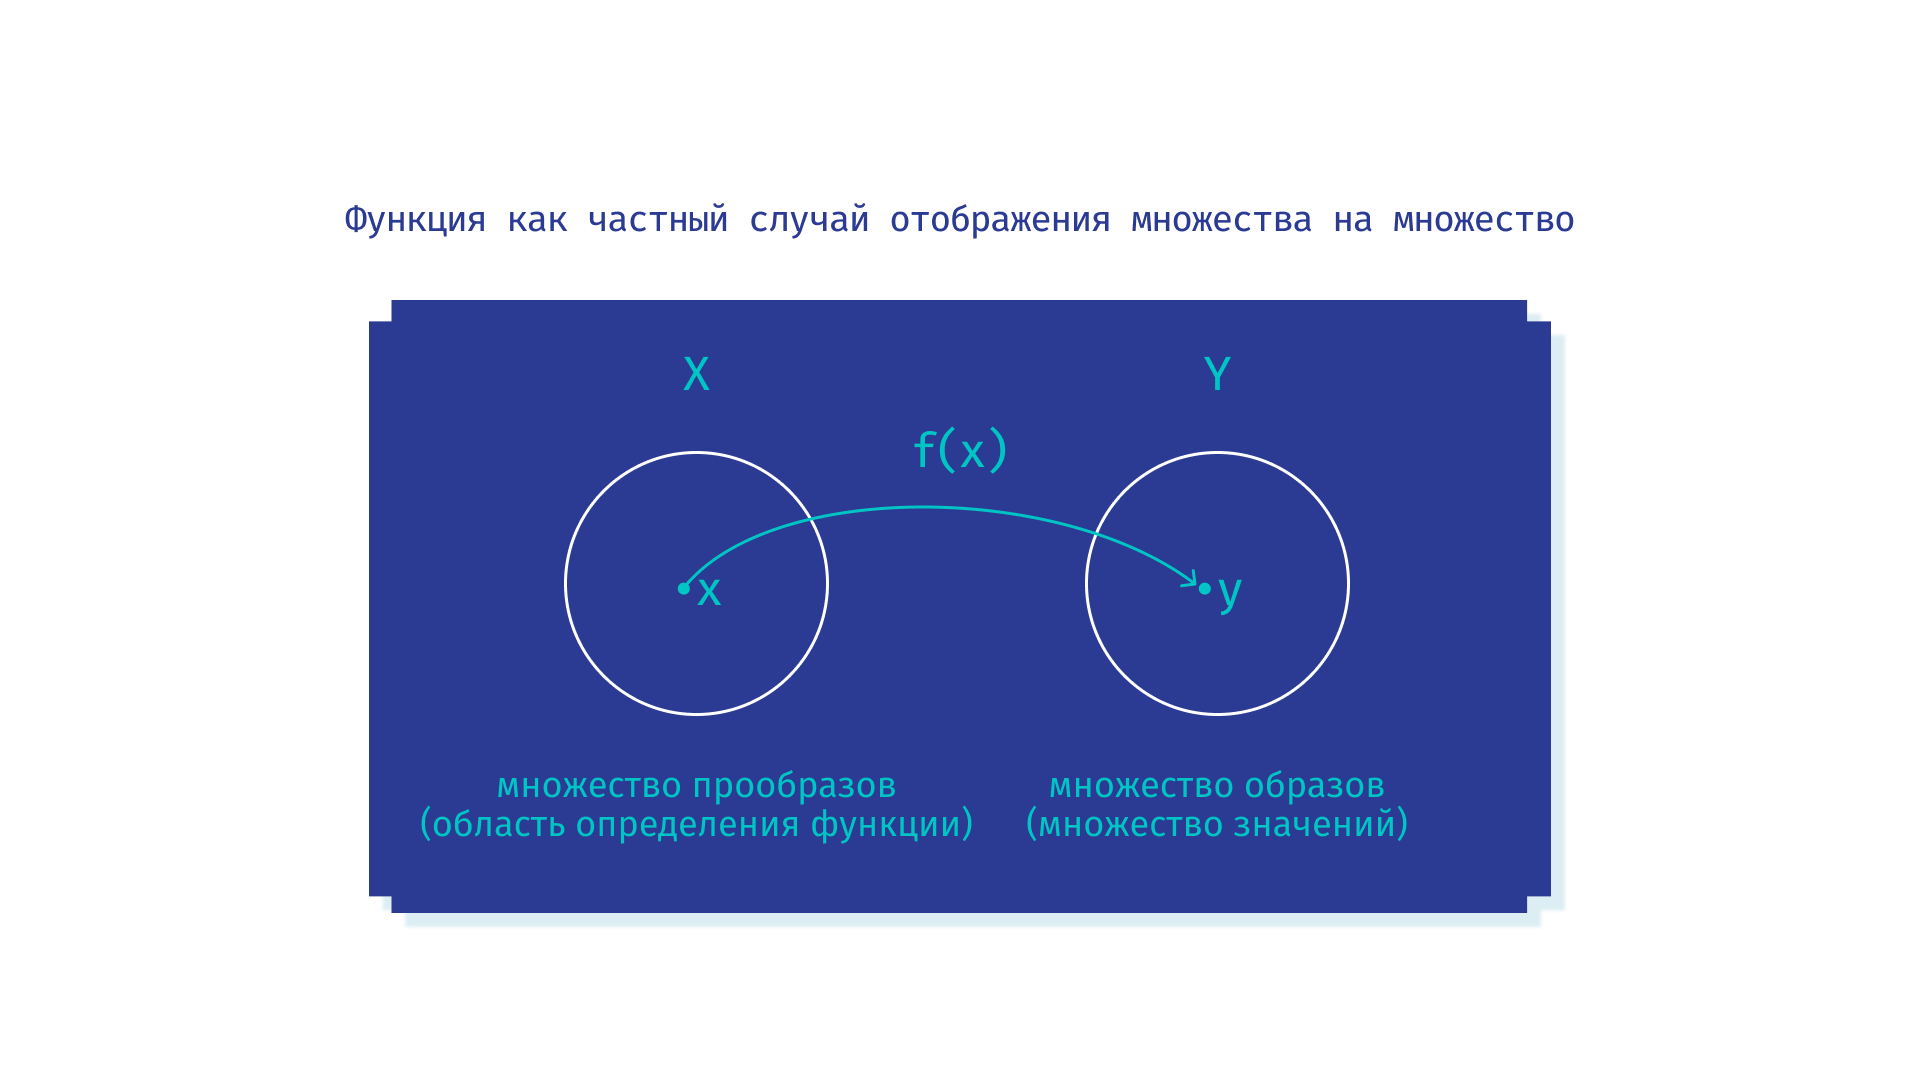

В программировании функция — это в первую очередь **алгоритм**:

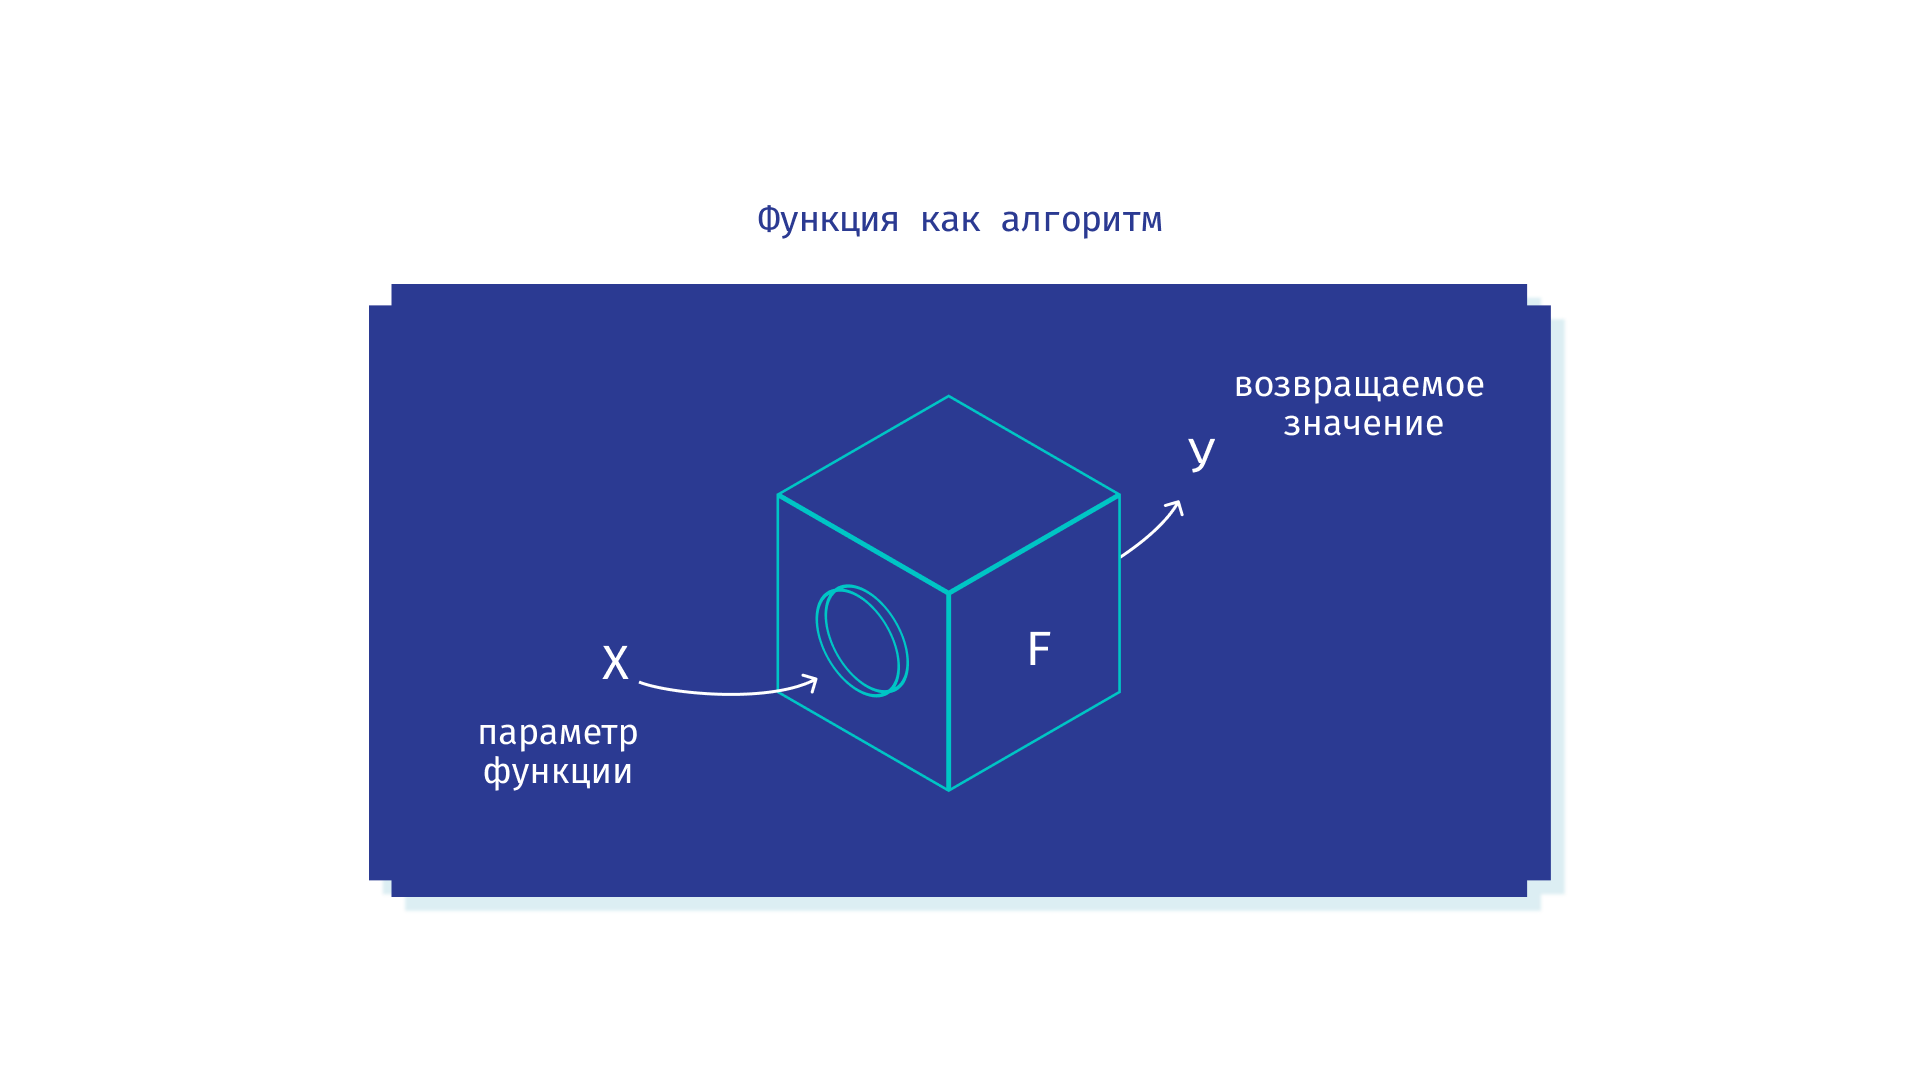

Если функция-алгоритм *делает* что-то кроме вычисления своего значения, или же её значение зависит от чего-то кроме параметров, то говорят, что функция имеет **побочные эффекты**.

Математические функции реализуются в программировании **чистыми функциями**: без побочных эффектов.

Чистые функции ничего *не* читают с клавиатуры и *не* пишут на экран, *не* работают с файлами.
Значения чистых функций *зависят только от значений параметров* и могут быть **закешированы**.
Это значит, что для каждого прообраза их можно вычислить только один раз, а потом только *вспоминать* ранее вычисленное значение.

### Создание пользовательской функции, возвращающей значение

Мы уже создавали функцию с `return` в прошлой лекции для поиска индекса буквы латинского алфавита. Рассмотрим общий вариант синтаксиса функции с несколькими параметрами:

```python
def название_функции(параметры, через, запятую):
    тело
    функции
    return выражение - являющееся * значением + функции
    # код, который никогда не выполнится
```

Оператор `return` не только возвращает значение выражения, но и является точкой выхода из функции.
То есть он *заканчивает выполнение команд* внутри функции, ведь все действия функции нужны были только ради поиска возвращаемого значения.

Слово `return` может встречаться не только в конце тела функции, но и во вложенных конструкциях — чаще всего в ветвлении `if`.

`maximum()` — пример чистой функции с двумя параметрами и двумя точками выхода:

In [ ]:
def maximum(a, b):
    if a > b:
        return a
    else:
        return b

In [ ]:
maximum(10, 20)

20

In [ ]:
maximum(20, 10)

20

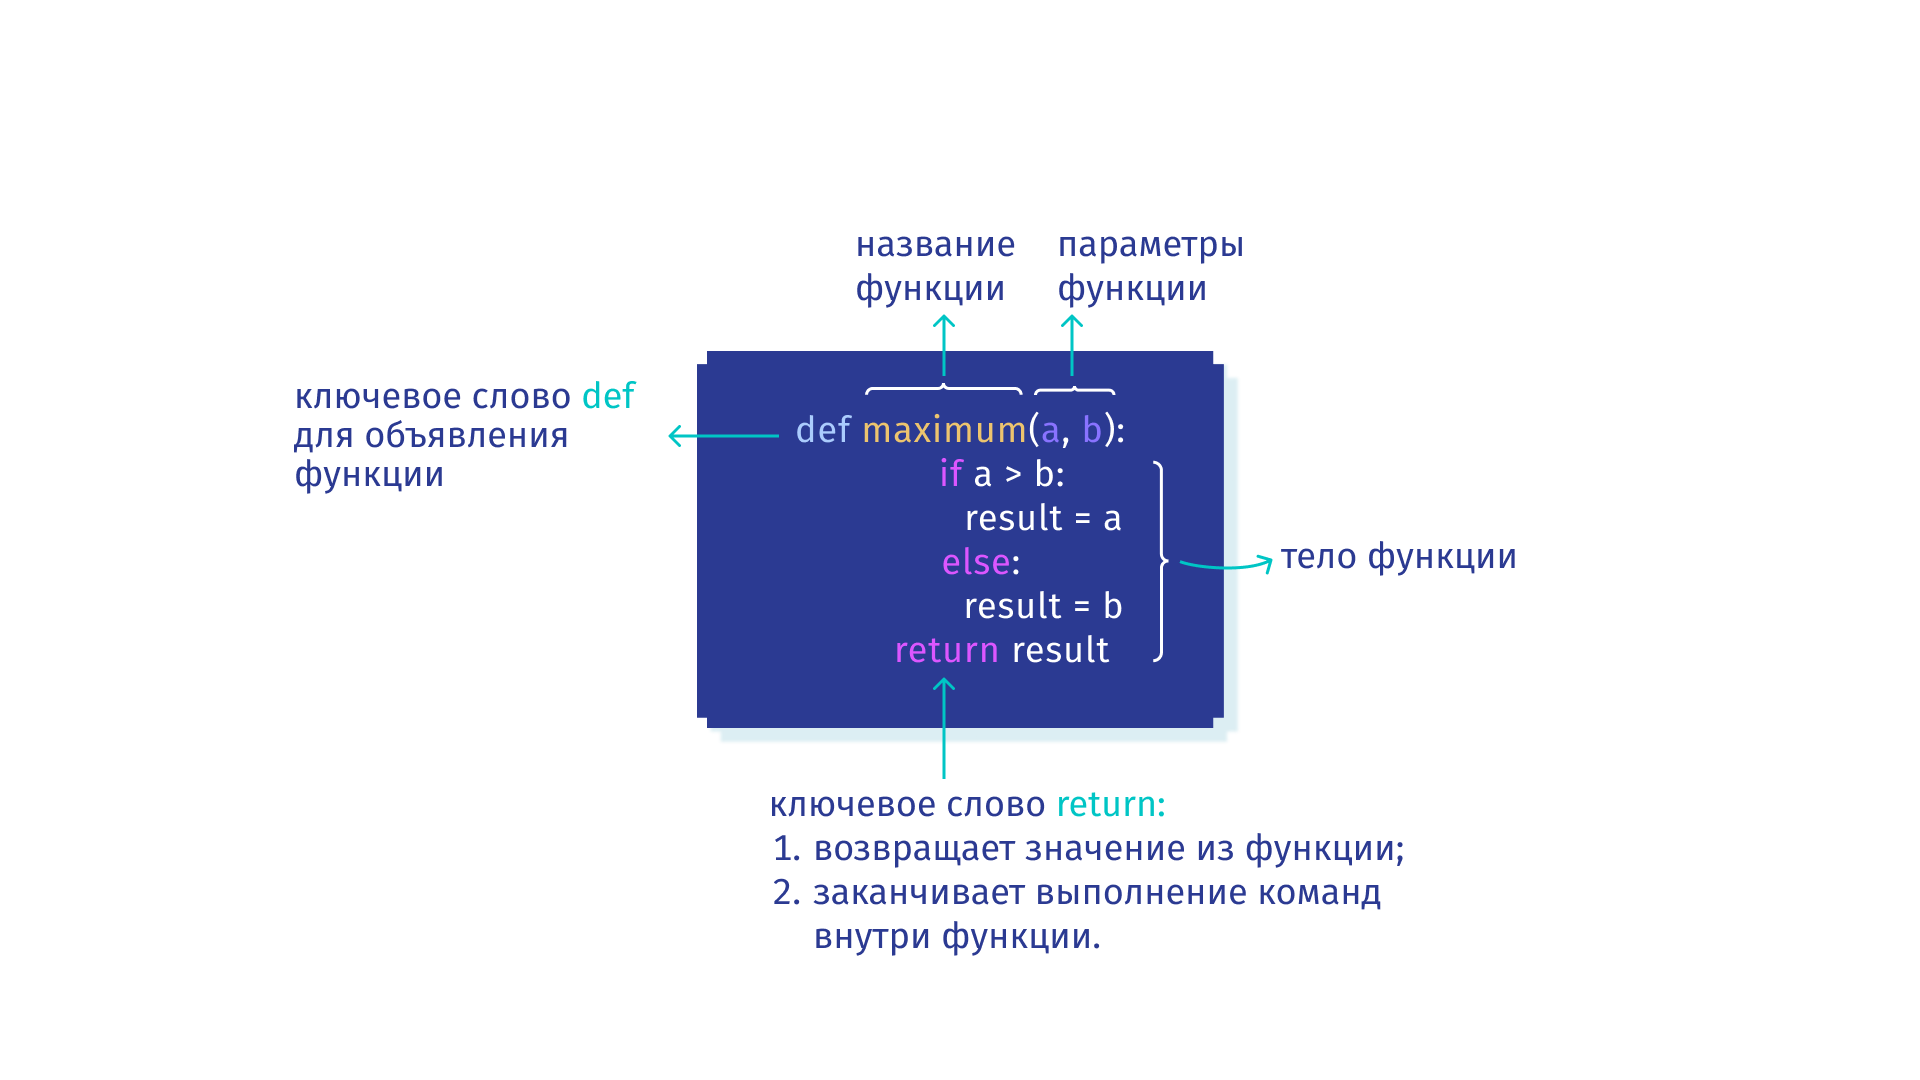

В данной функции можно убрать `else`. Почему?

In [ ]:
def maximum(a, b):
    if a > b:
        return a
    return b

In [ ]:
maximum(10, 20)

20

In [ ]:
maximum(20, 10)

20

### Библиотека `math`

Библиотека `math` — это стандартная библиотека Python, которая содержит известные вам из школы *математические функции одного вещественного переменного*.

Устанавливать библиотеку `math` не требуется, а подключается она так:

In [ ]:
import math

#### Тригонометрические функции

**Cинус** угла $sin(x)$ — это отношение длины противолежащего катета к длине гипотенузы, обобщённое для углов за пределами $[0, \pi]$.

**Косинус** угла $cos(x)$ — это отношение длины прилежащего катета к длине гипотенузы, также обобщённое для углов за пределами $[0, \pi]$.

Синус и косинус вычисляются при помощи `math.sin(x)` и `math.cos(x)`.

Давайте вычислим их значения для данного списка чисел `x` и отобразим их графики при помощи Matplotlib `plot()`:

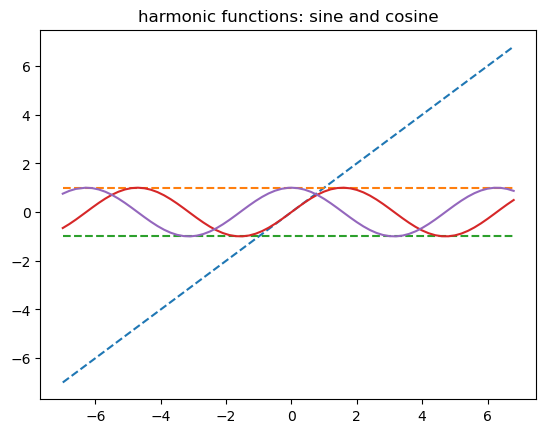

In [ ]:
x = [-7.0, -6.8, -6.6, -6.3, -6.1, -5.9, -5.7, -5.5, -5.3, -5.1, -4.9, -4.7, -4.5, -4.3, -4.1, -3.9,
     -3.7, -3.5, -3.3, -3.1, -2.9, -2.7, -2.5, -2.3, -2.1, -1.9, -1.7, -1.5, -1.3, -1.1, -0.9, -0.7,
     -0.5, -0.3, -0.1, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0,
     3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.2, 6.4, 6.6, 6.8]
sin_y = [math.sin(t) for t in x]
cos_y = [math.cos(t) for t in x]
plt.title("harmonic functions: sine and cosine")
plt.plot(x, x, '--', x, [1]*len(x), '--', x, [-1]*len(x), '--',
         x, sin_y, x, cos_y)
plt.show()

На графике `plot()` в одних осях отображены сразу пять функций: sin, cos, две константы и наклонная прямая $y = x$.

**Тангенс** — отношение противолежащего катета к прилежащему.

Функция тангенса имеет национальную особенность: tangent в русской и немецкой математической традиции пишется как **tg**, но в других европейских странах её сокращают как **tan**.

В Python следуют английской традиции и пишут `math.tan(x)`:

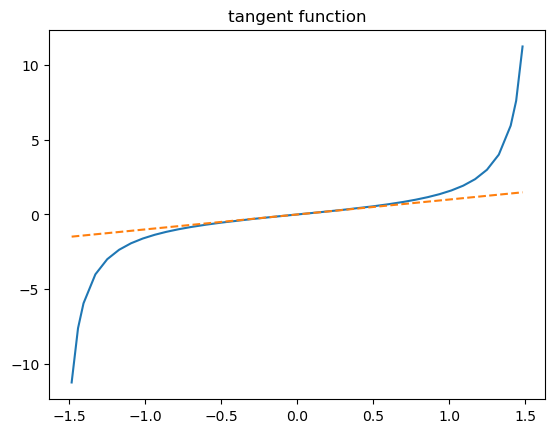

In [ ]:
x = [-1.482, -1.44, -1.404, -1.326, -1.248, -1.17, -1.092, -1.014, -0.936, -0.86, -0.78, -0.7, -0.6, -0.5, -0.3,
     -0.15, 0.0, 0.15, 0.3, 0.5, 0.6, 0.7, 0.78, 0.86, 0.936, 1.014, 1.092, 1.17, 1.248, 1.326, 1.404, 1.44, 1.482]
tan_y = [math.tan(t) for t in x]
plt.title("tangent function")
plt.plot(x, tan_y, '-', x, x, '--')
plt.show()

Вспомним, что в точках $\frac{\pi}{2} + \pi k, k \in Z$ функция тангенса терпит **разрыв**, поэтому отобразить её в промежутках, содержащих точки разрыва, сложно.

График `plot()` из-за разрывов функции *не соответствует реальности* и выглядит некрасиво:

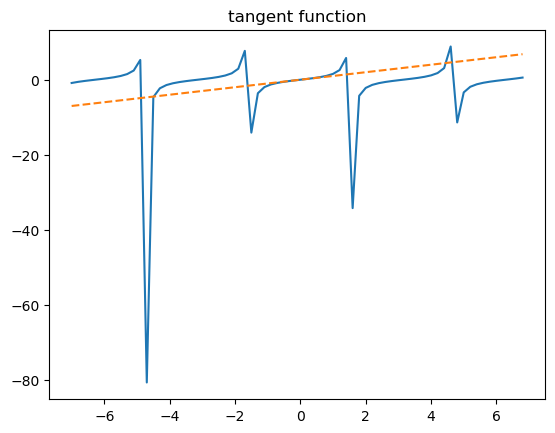

In [ ]:
x = [-7.0, -6.8, -6.6, -6.3, -6.1, -5.9, -5.7, -5.5, -5.3, -5.1, -4.9, -4.7, -4.5, -4.3, -4.1, -3.9,
     -3.7, -3.5, -3.3, -3.1, -2.9, -2.7, -2.5, -2.3, -2.1, -1.9, -1.7, -1.5, -1.3, -1.1, -0.9, -0.7,
     -0.5, -0.3, -0.1, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0,
     3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.2, 6.4, 6.6, 6.8]
tan_y = [math.tan(t) for t in x]
plt.title("tangent function")
plt.plot(x, tan_y, '-', x, x, '--')
plt.show()

#### Экспонента

**Экспонента** — это одна из показательных функций, таких как $2^{x}$, только основанием служит число $e = 2.718281828459045...$, которое так же трансцендентно, как и число $\pi$.

Для функции $e^{x}$ даже придумали специальное обозначение $\exp(x)$, и она лежит в математической библиотеке `math.exp(x)`:

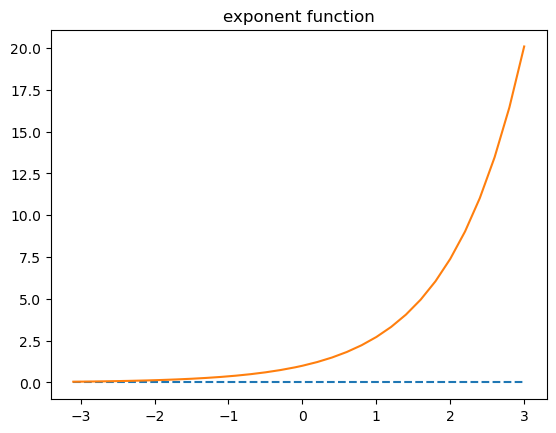

In [ ]:
x = [-3.1, -2.9, -2.7, -2.5, -2.3, -2.1, -1.9, -1.7, -1.5, -1.3, -1.1, -0.9, -0.7, -0.5, -0.3,
     -0.1, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
exp_y = [math.exp(t) for t in x]
plt.title("exponent function")
p = plt.plot(x, [0]*len(x), '--', x, exp_y)

Экспонента — одна из самых быстро растущих функций. При больших значениях x функция $e^x$ перерастает любую степенную функцию $y = x ^ n$ с любым значением числа n.

#### Логарифм

**Логарифм** — функция, обратная показательной, отвечает на вопрос "в какую степень нужно возвести A, чтобы получить B".

Функция $log_{A}{B}$ не определена для отрицательных чисел и нуля, а при приближении к нулю справа её значение уходит в бесконечность.

В math логарифм вычисляется через `math.log(A, B)`.
Если мы вызываем функцию `math.log(t)` с одним параметром, то возвращаемое значение — это *натуральный логарифм* (то есть основание равно числу `e`).

Отобразим графики логарифма по основанию 2 и натурального логарифма в диапазоне от 0.1 до 5:

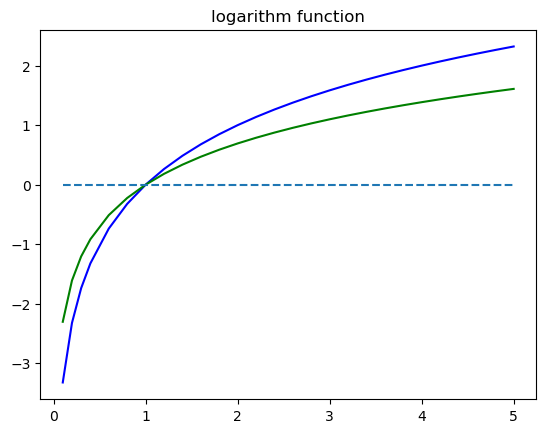

In [ ]:
x = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4,
     2.6, 2.8, 3.0,3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0]
log_y = [math.log(t, 2) for t in x]
log_y2 = [math.log(t) for t in x]
plt.title("logarithm function")
plt.plot(x, log_y, 'b', x, log_y2, 'g', x, [0]*len(x), '--')
plt.show()

Чем больше основание, тем медленнее растёт логарифм с увеличением $x$. Синим изображён логарифм по основанию 2, а зелёным — по основанию $e = 2.718281828459045$.

### Запись математических формул как выражений на Python

В математике для записи функций используются сложносоставные выражения, в которых могут быть дроби, показатели степени, корни.
Для вёрстки математических формул часто используется язык $\LaTeX $, интерпретация которого встроена в Jupyter.

Например, формула для корней квадратного уравнения: $ x_{1,2} = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} $

Изучение $\LaTeX $ очень полезно для написания курсовых и дипломных работ, а также для оформления статей в формате Jupyter ноутбуков, однако не входит в данный учебный курс.

Однако, при программировании часто возникает необходимость переписать подобную формулу в однострочное выражение, которое может быть интерпретировано Python.

#### Задача
Дано следующее математическое выражение:

$ e^{\frac{x}{2}+1} + e^{2 x + 1} \cdot \sin^2(5x + 3)$

Нужно переписать его как функцию `f()` на Python и построить её график.

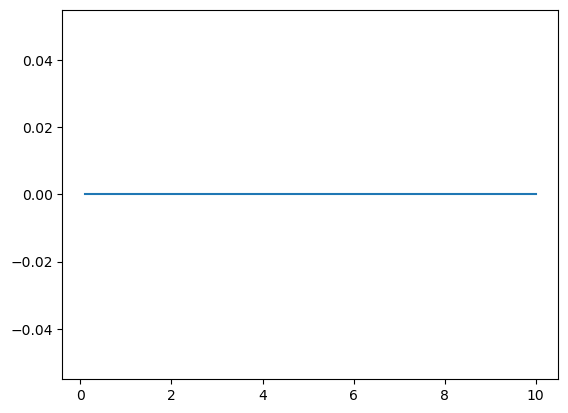

In [ ]:
import math
import matplotlib.pyplot as plt

def f(x: float) -> float:
    return 0  # FIXME

x = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05,
     1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05,
     2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7, 2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.05,
     3.1, 3.15, 3.2, 3.25, 3.3, 3.35, 3.4, 3.45, 3.5, 3.55, 3.6, 3.65, 3.7, 3.75, 3.8, 3.85, 3.9, 3.95, 4.0, 4.05,
     4.1, 4.15, 4.2, 4.25, 4.3, 4.35, 4.4, 4.45, 4.5, 4.55, 4.6, 4.65, 4.7, 4.75, 4.8, 4.85, 4.9, 4.95, 5.0, 5.05,
     5.1, 5.15, 5.2, 5.25, 5.3, 5.35, 5.4, 5.45, 5.5, 5.55, 5.6, 5.65, 5.7, 5.75, 5.8, 5.85, 5.9, 5.95, 6.0, 6.05,
     6.1, 6.15, 6.2, 6.25, 6.3, 6.35, 6.4, 6.45, 6.5, 6.55, 6.6, 6.65, 6.7, 6.75, 6.8, 6.85, 6.9, 6.95, 7.0, 7.05,
     7.1, 7.15, 7.2, 7.25, 7.3, 7.35, 7.4, 7.45, 7.5, 7.55, 7.6, 7.65, 7.7, 7.75, 7.8, 7.85, 7.9, 7.95, 8.0, 8.05,
     8.1, 8.15, 8.2, 8.25, 8.3, 8.35, 8.4, 8.45, 8.5, 8.55, 8.6, 8.65, 8.7, 8.75, 8.8, 8.85, 8.9, 8.95, 9.0, 9.05,
     9.1, 9.15, 9.2, 9.25, 9.3, 9.35, 9.4, 9.45, 9.5, 9.55, 9.6, 9.65, 9.7, 9.75, 9.8, 9.85, 9.9, 9.95, 10.0]
y = [f(t) for t in x]
plt.plot(x, y)

## Поиск корня уравнения методом деления пополам

Легенда к задаче:
> Студент-геолог после фильма "Послезавтра" увлёкся [палеоклиматологией](https://ru.wikipedia.org/wiki/%D0%9F%D0%B0%D0%BB%D0%B5%D0%BE%D0%BA%D0%BB%D0%B8%D0%BC%D0%B0%D1%82%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%8F). Он предполагает, что за глобальным потеплением межледниковья внезапно наступит новая ледниковая эпоха ледникового периода, и хочет исследовать такие моменты для прошлых ледниковых эпох. У него есть готовая математическая модель для одной из ледниковых эпох — функция средней по земле температуры (по Цельсию) от времени:
>
$$ Temperature(t) = \arctan(-0.0012 t^3 + 0.4 t^2+ 0.616 t + 6120) + 0.65 \sin(0.24 t + 1.23)  - 0.27 \cos(0.21 t - 0.17) - \frac{\sin(0.34 t + 0.16)}{1 + 0.03 (t - 370.5)^2} $$
>
> Промежуток времени, в рамках которого построена модель, затрагивает годы от условного 0 до 1000.
> Как геологу найти момент перехода средней температуры с положительной на отрицательную с ошибкой не более 1 года?

Первое, что нужно осознать, — это бесперспективность решения уравнения $Temperature(t) = 0$ аналитическими методами (с бумагой и ручкой).

Что делать? Для начала нарисуем график этой функции в указанном диапазоне с шагом 1:

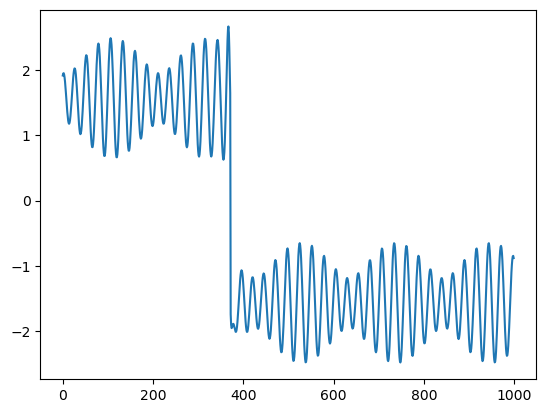

In [ ]:
import math
def temperature(t: float) -> float:
    return math.atan(-0.0012*t**3 + 0.4*t**2 + 0.616*t + 6120) + \
               0.65*math.sin(0.24*t + 1.23) - \
               0.27*math.cos(0.21*t - 0.17) - \
               math.sin(0.34*t + 0.16) / (1 + 0.03*(t - 370.5)**2)

x = list(range(0, 1000, 1))
y = [temperature(t) for t in x]
plt.plot(x, y)
plt.show()

Видно, что корень уравнения на этом промежутке есть. Очевидная идея — решение "глазами", приближение к корню. Рисовать график всё ближе и ближе. Но этот способ хочется автоматизировать.

Применим идею **двоичного поиска**. Выберем такие границы, где значение функции точно больше и точно меньше нуля, — от 0 до 1000. Выберем значение в середине этого отрезка. Если оно меньше, чем заданное, то сместим левую границу в середину отрезка. В противном случае сместим правую границу. Далее повторим процесс сужения границ.

Остановиться мы можем тогда, когда расстояние между левой и правой границами будет меньше удвоенной ошибки. В нашей задаче это 1.

In [ ]:
left_boundary, right_boundary = (0, 1000)
supposed_error = 1.0e-5

while right_boundary - left_boundary > 2*supposed_error:
    middle = (right_boundary + left_boundary) / 2
    if temperature(middle) > 0:
        left_boundary = middle
    else:
        right_boundary = middle

the_answer = (right_boundary + left_boundary) / 2
print("Ледниковая эпоха наступит в", f"{the_answer:.7}", "году.")

Ледниковая эпоха наступит в 371.6395 году.


## Основы NumPy

Для работы с массивами чисел большинство аналитиков данных пользуются библиотекой **NumPy**.
Это библиотека с *открытым исходным кодом*, в которой реализованы сложные математические функции для работы с массивами как с векторами и матрицами.
Документация по библиотеке NumPy на английском языке есть [на официальном сайте](https://numpy.org/).

Для работы в Jupyter на локальном компьютере установите NumPy [по инструкции](https://numpy.org/install/).
Если вы пользуетесь Google Colab, устанавливать NumPy не требуется.

Подключение NumPy чаще всего делают под псевдонимом `np`:

In [ ]:
import numpy as np

### Массивы `np.ndarray`

В NumPy описаны **`ndarray` — многомерные массивы**.

Создавать их удобно при помощи различных функций, например через `np.array`:

In [ ]:
A = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print(type(A))
A

<class 'numpy.ndarray'>


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

`np.zeros()` создаёт массив, заполненный нулями:

In [ ]:
B = np.zeros(10, dtype=np.float64)
B[4] = 12
B

array([ 0.,  0.,  0.,  0., 12.,  0.,  0.,  0.,  0.,  0.])

`np.ones()` создаёт массив, заполненный единицами:

In [ ]:
np.ones(10)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Функция `np.arange` генерирует массив со значениями в указаном диапазоне.

Параметры аналогичны классическому `range`. Если указано одно число, то левая граница прогрессии — ноль:

In [ ]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Укажем правую границу. Как и у обычного `range`, она не входит в диапазон:

In [ ]:
np.arange(5, 15)

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

Третий параметр `np.arange` — *шаг* прогрессии. Не всегда при этом легко сказать, сколько чисел получится в этом массиве.

In [ ]:
np.arange(10, 100, 15)

array([10, 25, 40, 55, 70, 85])

`np.arange` работает с дробными границами и шагом:

In [ ]:
np.arange(0.2, 10.9, 0.5)

array([ 0.2,  0.7,  1.2,  1.7,  2.2,  2.7,  3.2,  3.7,  4.2,  4.7,  5.2,
        5.7,  6.2,  6.7,  7.2,  7.7,  8.2,  8.7,  9.2,  9.7, 10.2, 10.7])

Обратите внимание, что в отличие от генератора арифметических прогрессий `range`, функция `np.arange` реально создаёт массив с числами в памяти.

Значения в массиве *можно менять*:

In [ ]:
A = np.arange(10)
A[0] = 1000
A[-1] = 999
A

array([1000,    1,    2,    3,    4,    5,    6,    7,    8,  999])

Функция `np.linspace` похожа на `np.range`, но создаёт массив с заданным *количеством элементов*, а шаг вычисляется автоматически:

In [ ]:
np.linspace(0, 10, 101)

array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. ])

Правая граница при этом *входит* в набор чисел.

Такой способ генерации массива очень удобен для последующего рисования графиков функций в указанном промежутке с заданным количеством точек.

### Векторные операции с массивами

Одна из удобных возможностей NumPy — это *массовые операции с массивами*, которые ещё и быстро работают.

Давайте посмотрим на отличие поведения `list` и `np.ndarray` при умножении на число:

In [ ]:
A = [1, 2, 3, 4, 5]
B = A * 5
print(B)

A = np.arange(1, 6)
B = A * 5
print(B)

[1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5]
[ 5 10 15 20 25]


In [ ]:
np.sin(B)

array([-0.95892427, -0.54402111,  0.65028784,  0.91294525, -0.13235175])

In [ ]:
np.exp(B)

array([1.48413159e+02, 2.20264658e+04, 3.26901737e+06, 4.85165195e+08,
       7.20048993e+10])

In [ ]:
np.log(B)

array([1.60943791, 2.30258509, 2.7080502 , 2.99573227, 3.21887582])

Векторные операции дают возможность оперативно подготавливать данные для отображения на графиках.

Визуализируем некоторые математические функции:

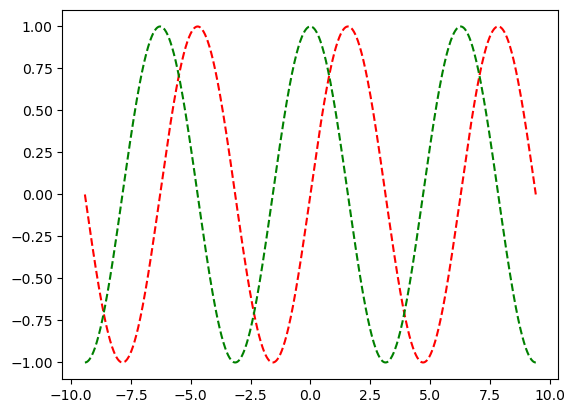

In [ ]:
x = np.linspace(-3*np.pi, +3*np.pi, 1000)
sin_x = np.sin(x)
cos_x = np.cos(x)
plt.plot(x, sin_x, 'r--', x, cos_x, 'g--')
plt.show()

### Срезы массивов NumPy

Как и в случае обычных списков, большое значение для работы с numpy.array имеют срезы. Срезы позволяют нам составлять новый массив из старого по определенному условию на координаты. Синтаксис очень похож на срезы списков.

Например, пусть мы хотим выбрать все значения массива A, индексы которых находятся в диапазоне 3:8 (3 — включается, 8 — не включается)

In [ ]:
A = np.arange(0, 15, 1)
A[3:8]

array([3, 4, 5, 6, 7])

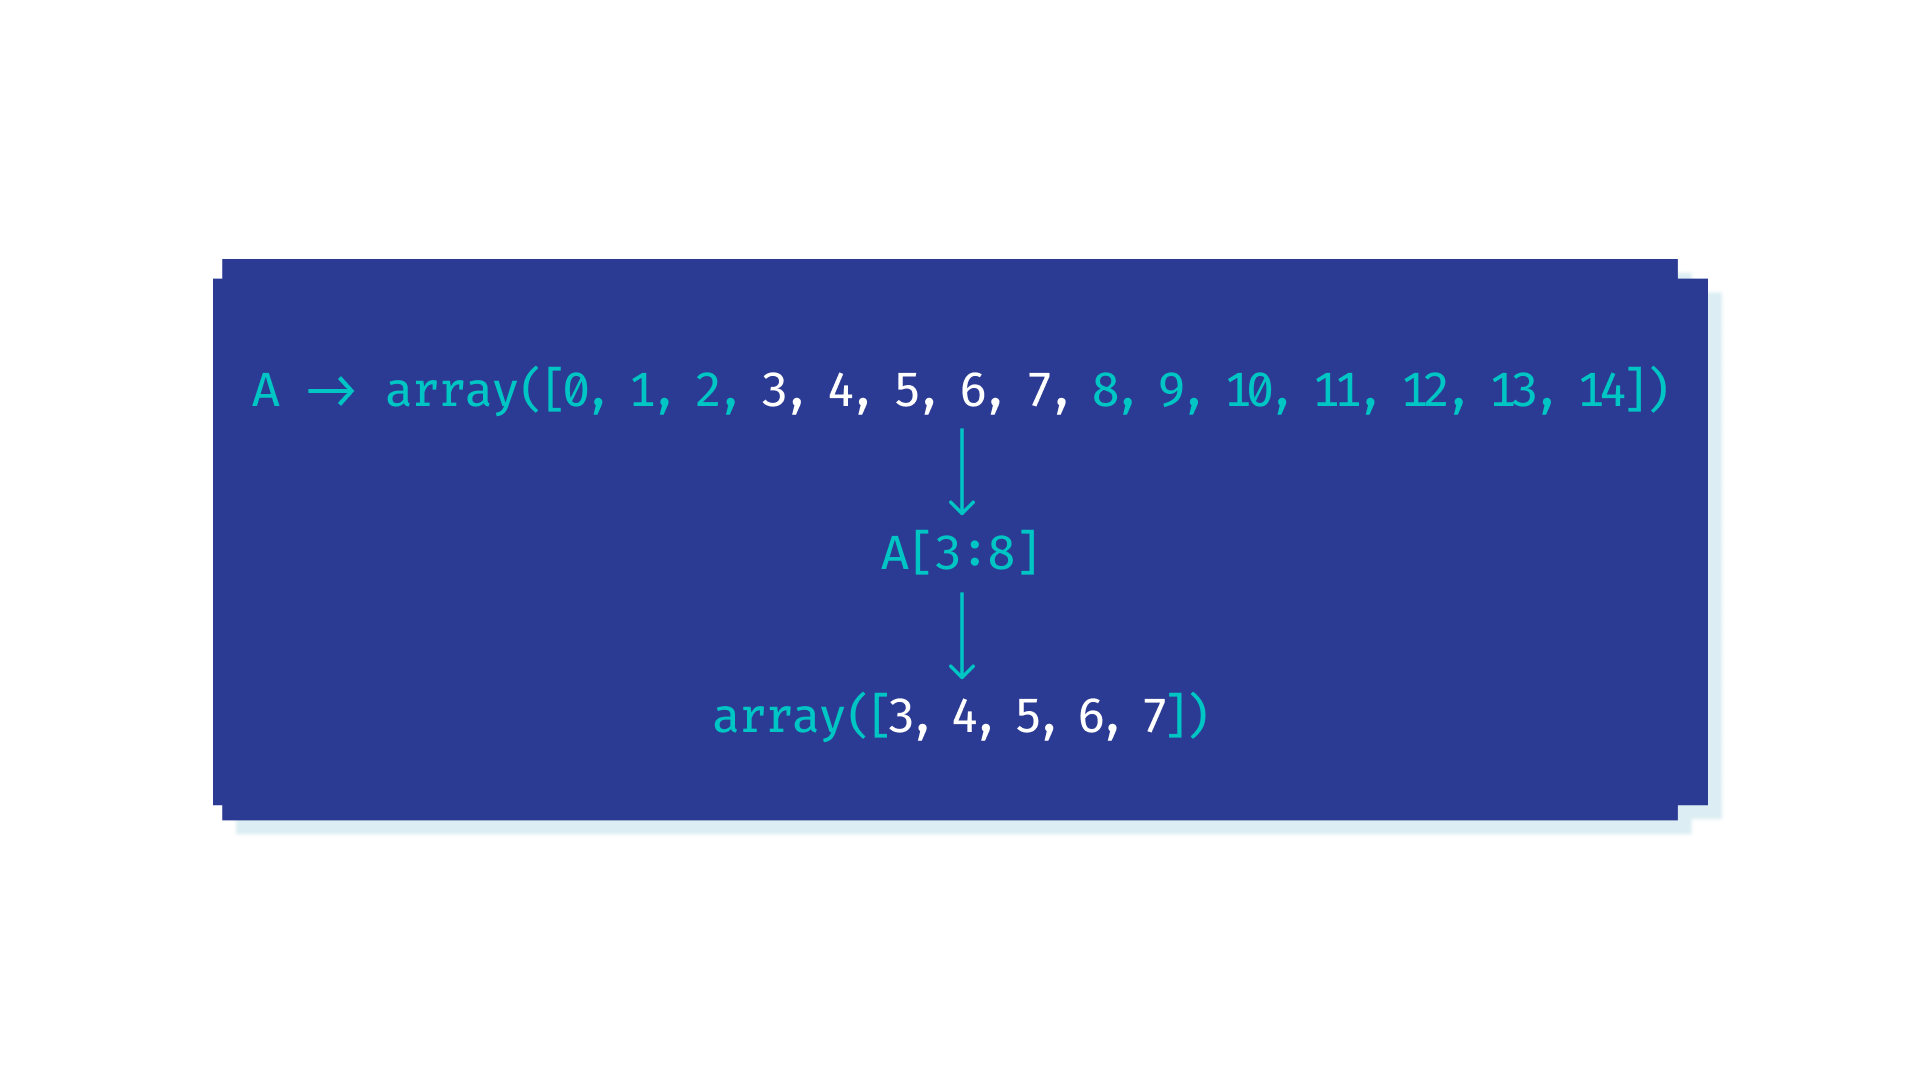

Как и в случае со списками, мы можем выбрать при помощи среза каждый n-й элемент, начиная с нужного нам (например, каждый четный или каждый нечетный элемент, каждый третий, четвертый и т.д.).
Делается это при помощи среза с тремя параметрами `[start:stop:step]`. То есть, если мы хотим выбрать все элементы, начиная с i-го, заканчивая j-м, с шагом k, мы сделаем это при помощи следующей конструкции:

`A[i:j:k]`

При этом любое из этих чисел можно опустить, и вместо него будет выбрано значение по умолчанию:
для start это 0,
для stop - длина массива,
для step - 1.

Например, выберем каждое второе число из диапазона индексов от 6 включительно до 14 (не включительно):

In [ ]:
A[6:14:2]

array([ 6,  8, 10, 12])

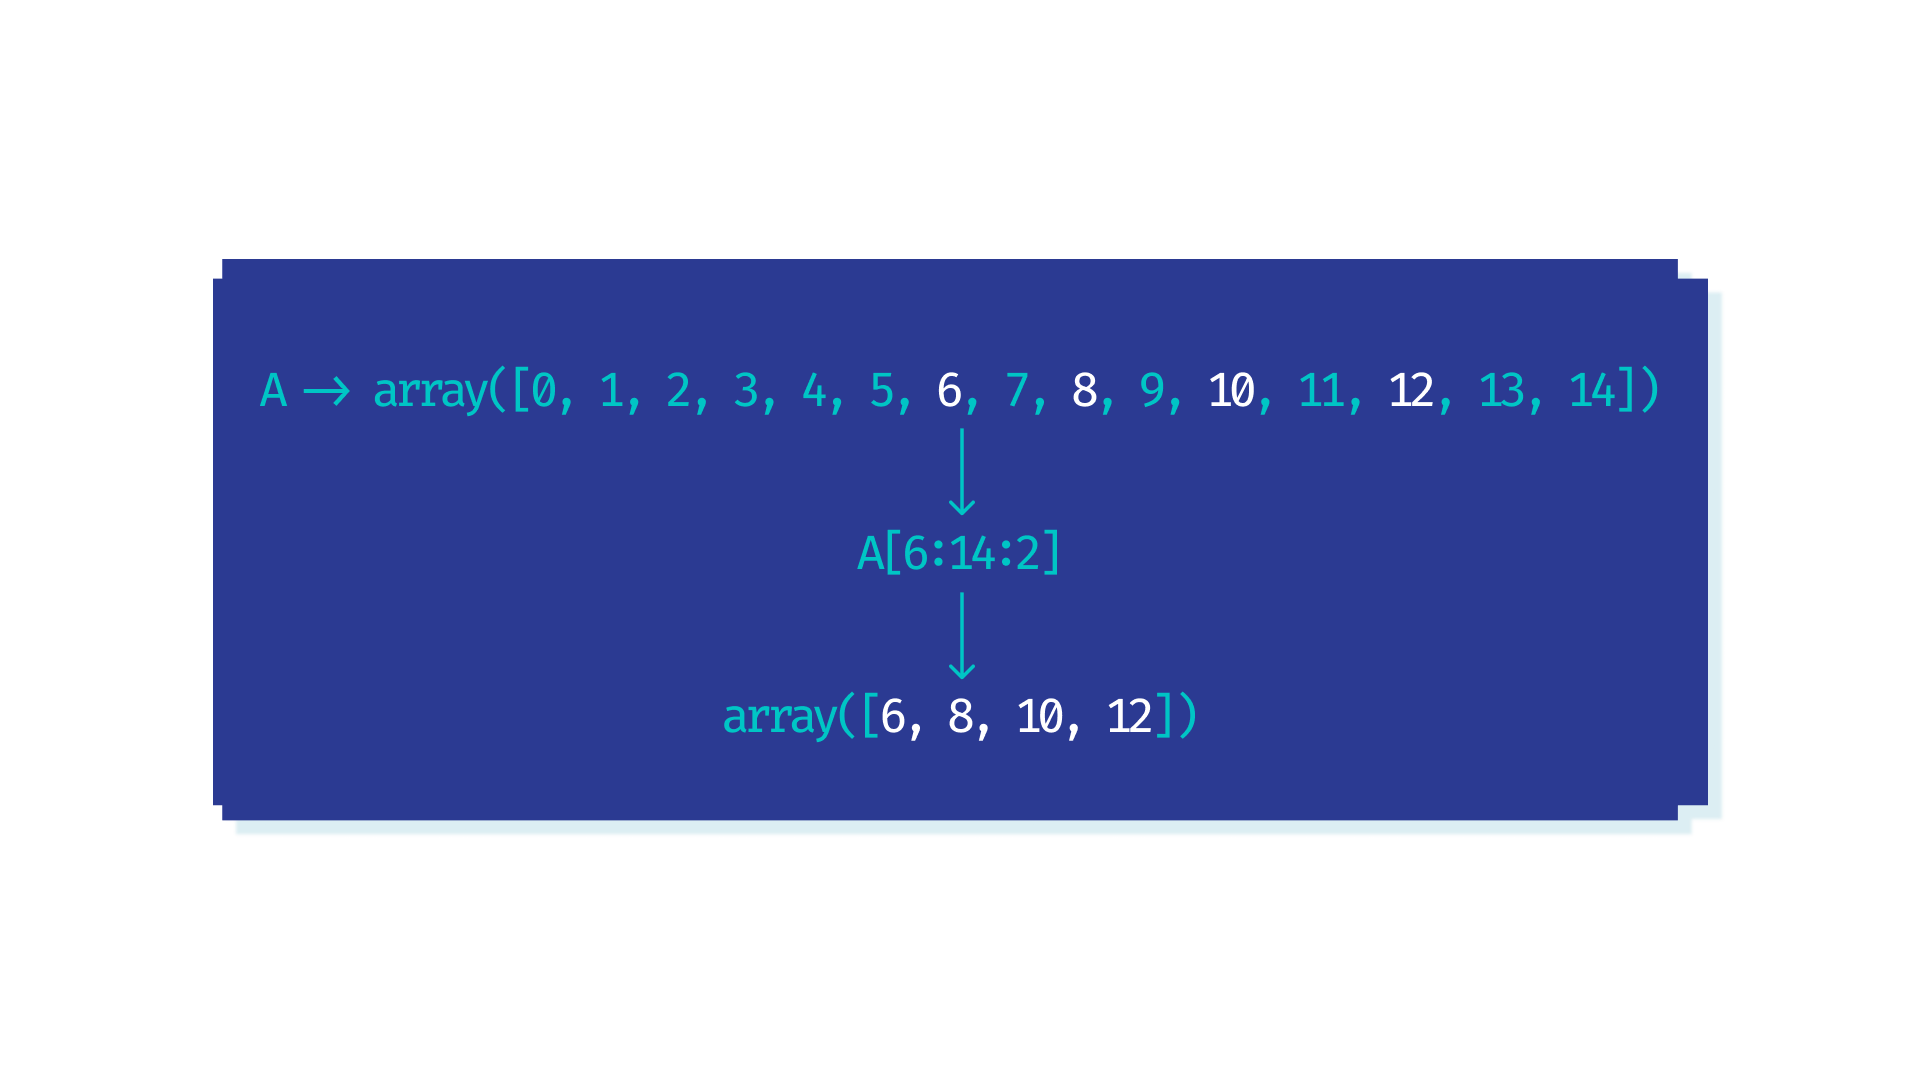

Возможно также использование отрицательных значений для всех трех индексов.

В случае со `start` и `stop` будет вестись отсчёт индекса с конца массива, а в случае со `step` само 'движение' по массиву пойдет в обратную сторону.

In [ ]:
A[-1]

14

In [ ]:
#start
A[-10: : ]

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

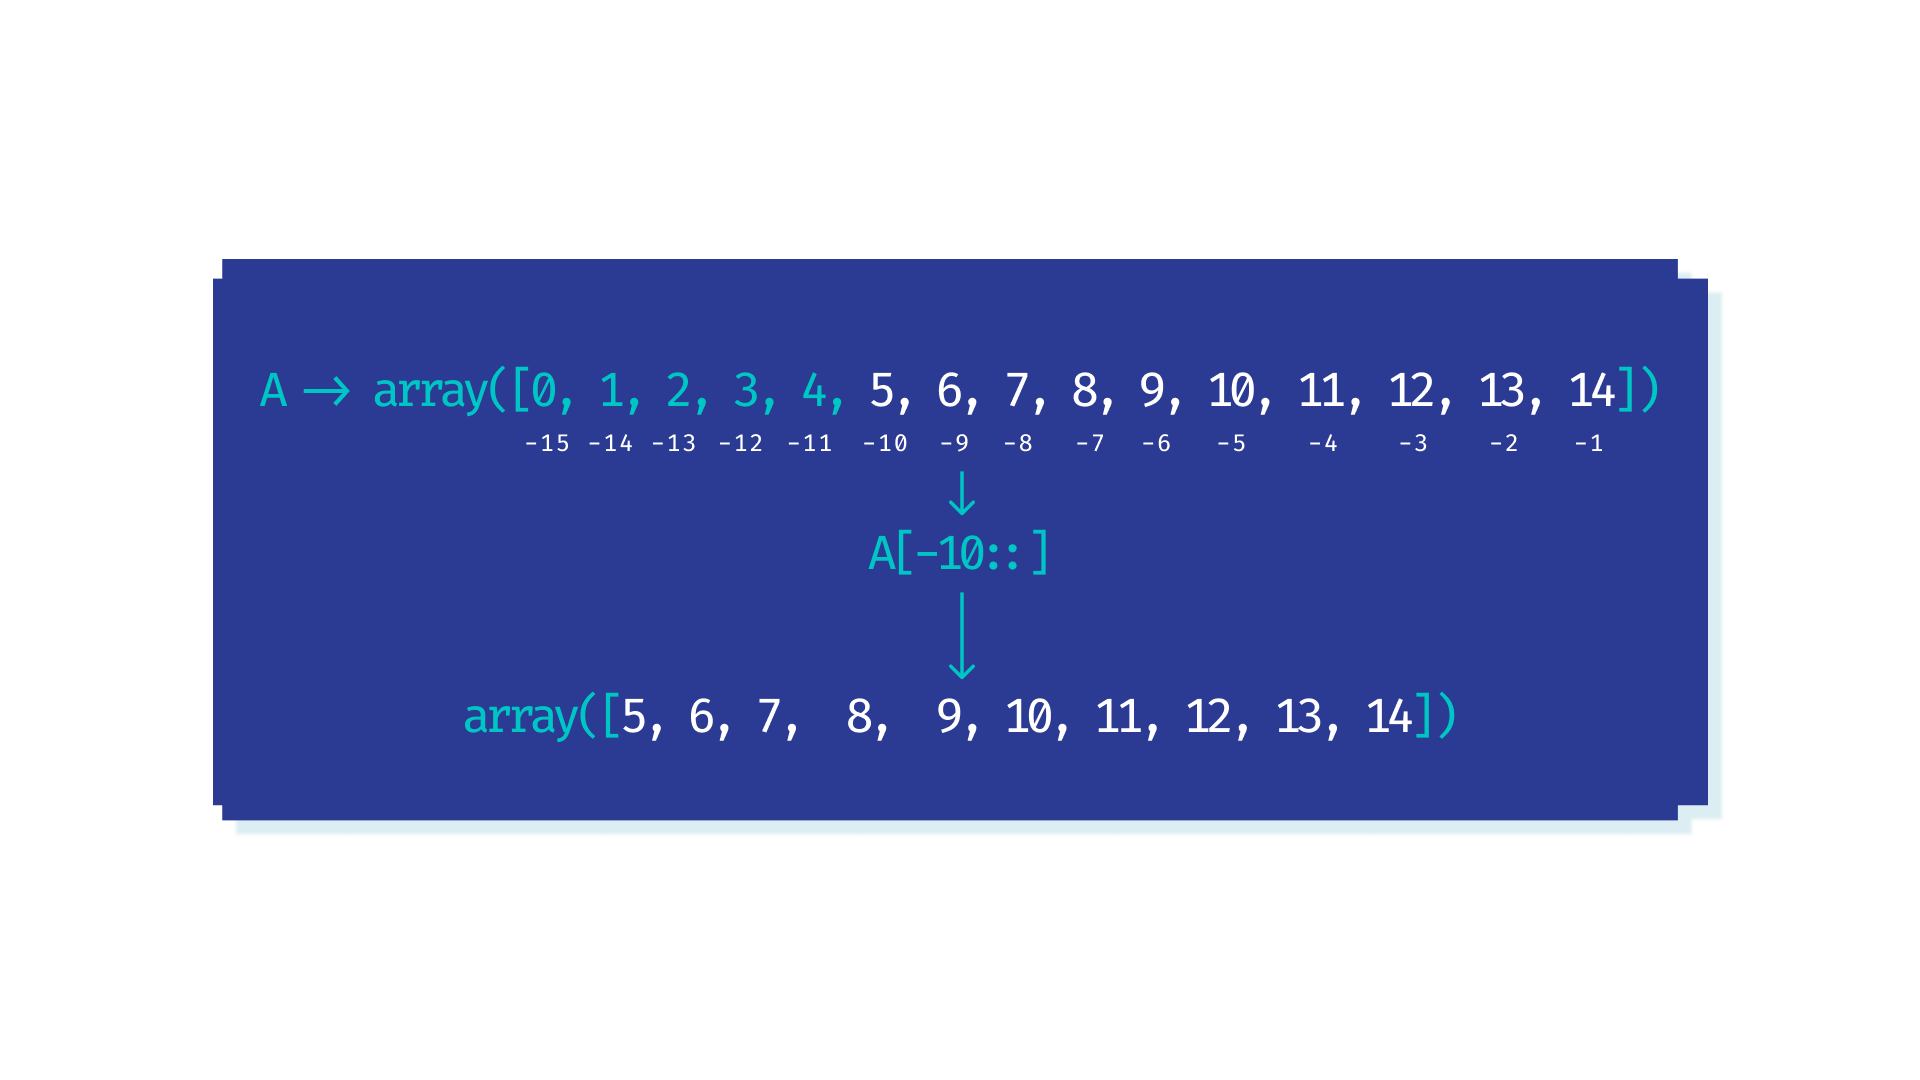

In [ ]:
#stop
A[ :-10: ]

array([0, 1, 2, 3, 4])

In [ ]:
#step
A[::-1]

array([14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

Если шаг положительный, то предполагается, что `start < stop` для значений `start` и `stop`, имеющих один знак. Иначе получим пустой массив:

In [ ]:
A[-6:-8:1]

array([], dtype=int64)

In [ ]:
A[8:6:1]

array([], dtype=int64)

In [ ]:
A[-8:-6:-1]

array([], dtype=int64)

В отличие от пустых списков, пустые массивы NumPy бессмысленны: в них нельзя добавить новые элементы. Метода `append` для них не существует!

Выберем из массива A вторую треть, а из нее - каждый второй элемент

In [ ]:
start = int(len(A)/3)
stop = -start
step = 2

A[start:stop:step]

array([5, 7, 9])

**Замечание**: значения start, stop и step ОБЯЗАТЕЛЬНО должны иметь тип integer

Возможная ошибка:

In [ ]:
A[len(A)/3: -len(A)/3: 3]

TypeError: slice indices must be integers or None or have an __index__ method

Она связана с тем, что значение len(A)/3 до приведения к типу int является типом float

### Присваивание в срез массива

Как и в случае со списками, для `np.ndarray` существует механизм **присваивания в срез**.

Элементы массива, выделенные при помощи среза, можно изменять присваиванием. При этом присваивать можно элементы другого **массива аналогичной формы** или же **константу**.

Присвоим каждому второму элементу A значение 0.

In [ ]:
A[::2] = 0
A

array([ 0,  1,  0,  3,  0,  5,  0,  7,  0,  9,  0, 11,  0, 13,  0])

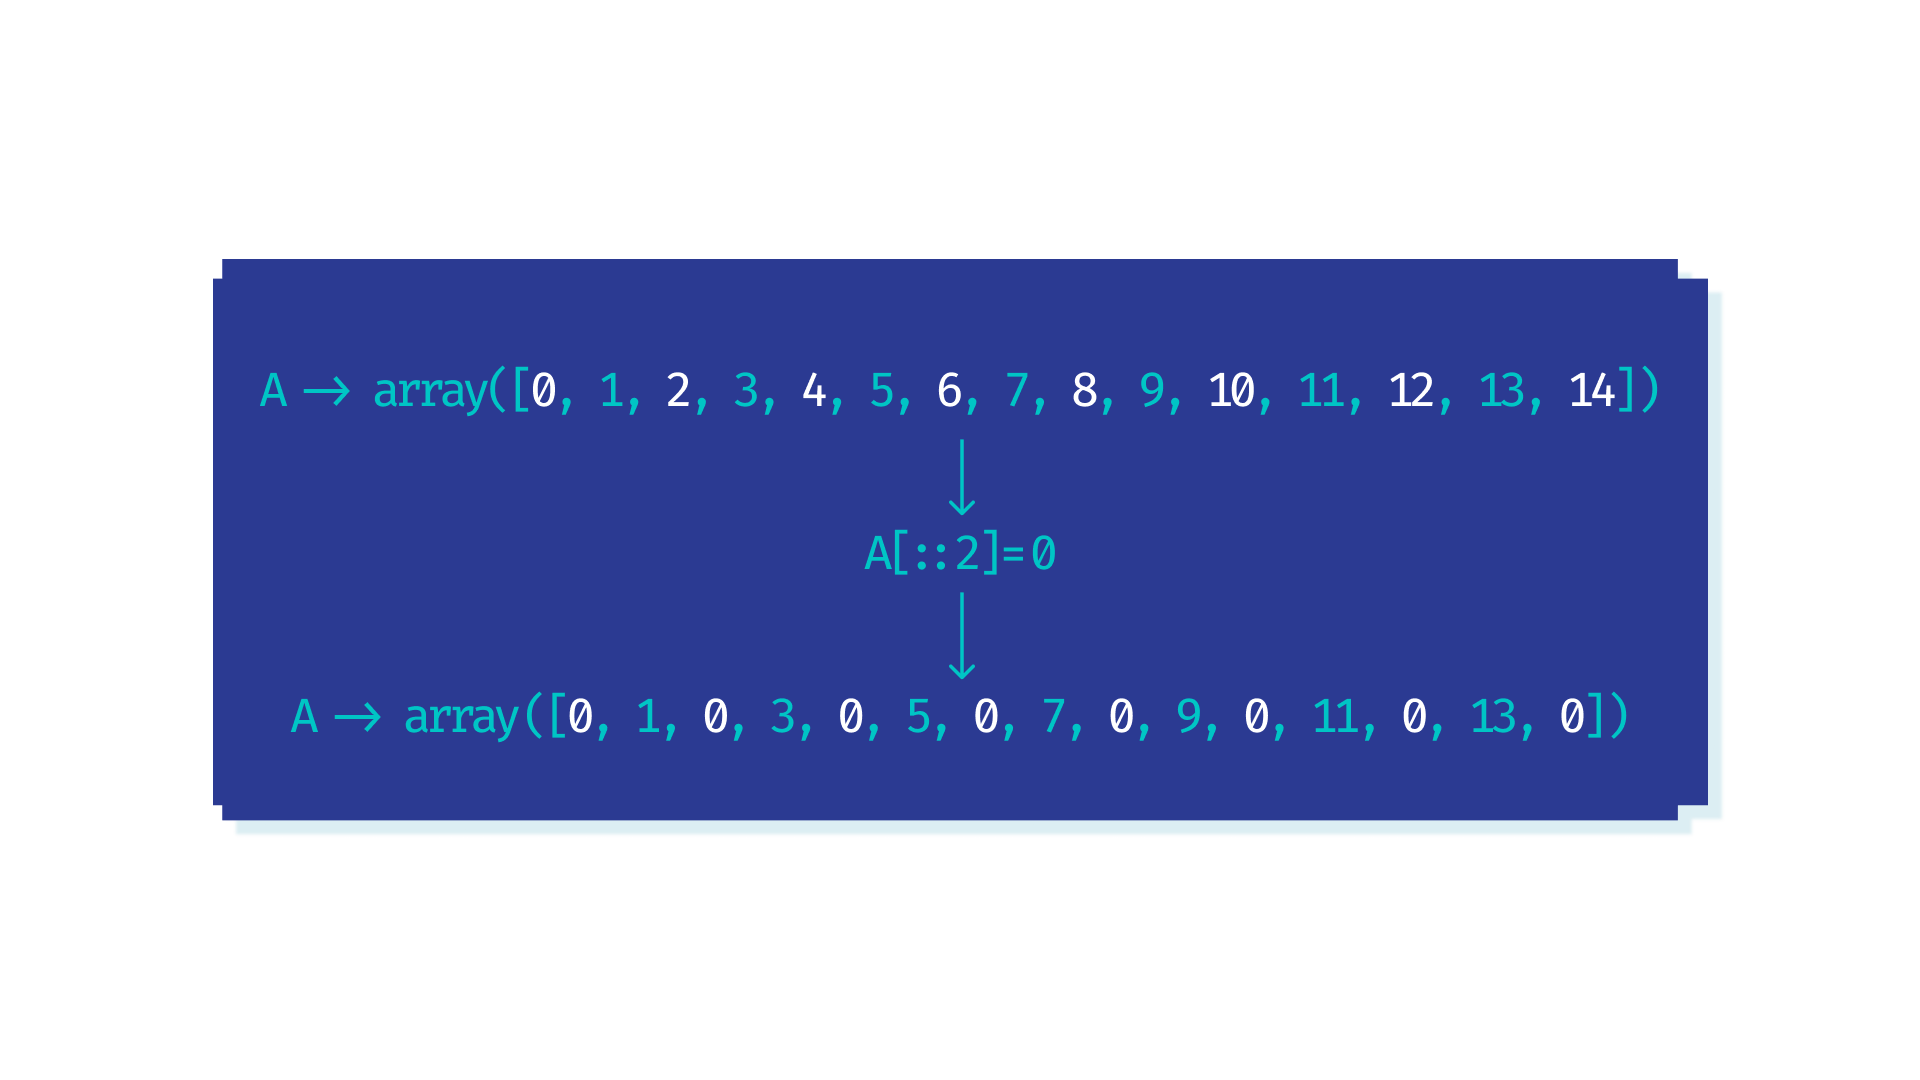

Присвоить в срез можно, например, другой срез. Заменим теперь все нули развернутым массивом из ненулевых элементов

In [ ]:
A[:-2:2] = A[-2:0:-2]

In [ ]:
A

array([13,  1, 11,  3,  9,  5,  7,  7,  5,  9,  3, 11,  1, 13,  0])

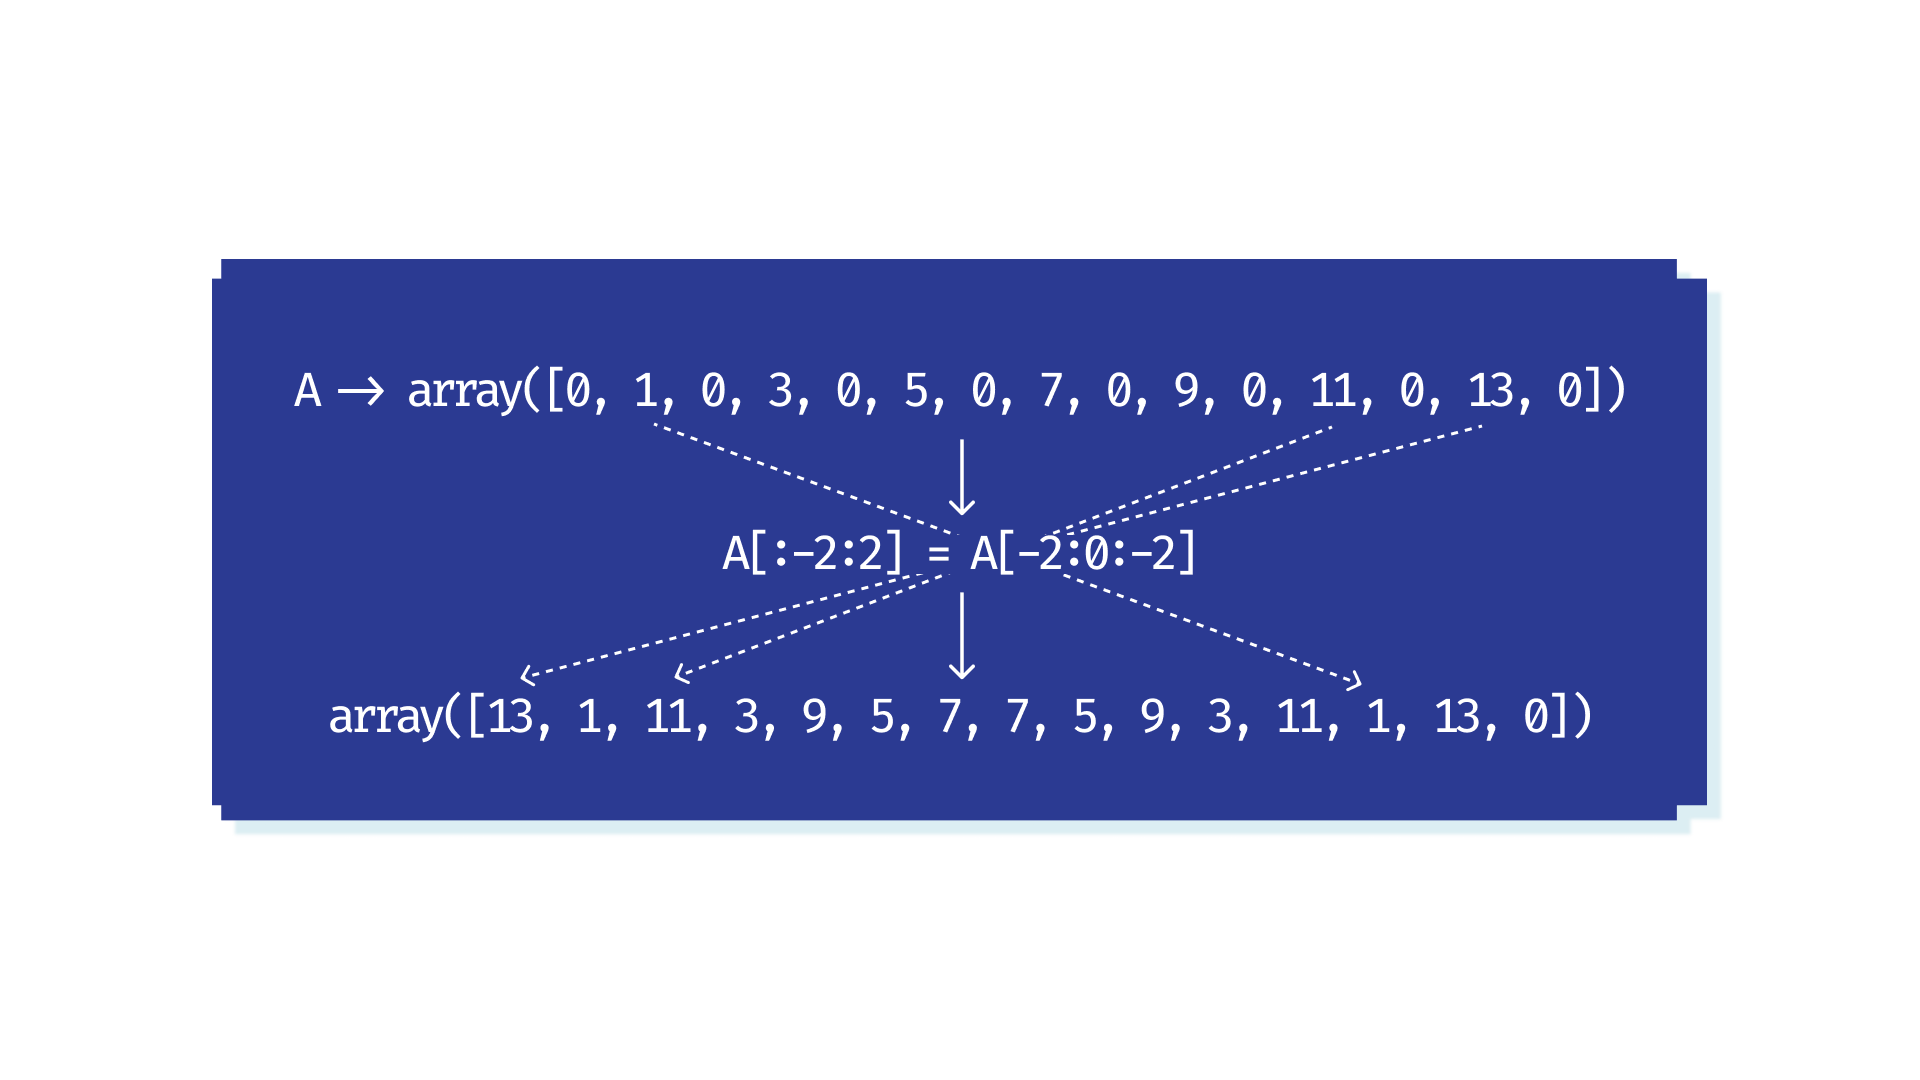

Или же можно присвоить какую-то константу, скажем, усреднить:

присвоим каждому второму элементу массива А из диапазона индексов 2 : -2 среднее значение элементов массива, воспользовавшись функцией поиска среднего np.mean(array)

In [ ]:
print(np.mean(A))
A[2:-2:2] = np.mean(A)  # НЕЯВНОЕ ПРИВЕДЕНИЕ ТИПА!

print(type(np.mean(A)))
print(A.dtype)

6.533333333333333
<class 'numpy.float64'>
int64


In [ ]:
A

array([13,  1,  6,  3,  6,  5,  6,  7,  6,  9,  6, 11,  6, 13,  0])

## Числа с плавающей точкой и ошибки вычислений

### Кодирование дробных чисел в двоичный код

Множество действительных чисел является континуальным множеством. Это означает, что действительные числа нельзя "пересчитать", поэтому, сколько бы мы ни взяли бит, мы неизбежно столкнемся с числами, которые не имеют точного представления, и их нельзя представить при помощи конечного числа бит.

Числа с плавающей запятой являются одним из возможных способов представления действительных чисел. Данное представление действительных чисел является компромиссом между точностью и диапазоном принимаемых значений.

Число с плавающей запятой состоит из трех блоков разрядов:
- знак
- порядок
- мантисса

Порядок и мантисса — это целые числа, которые вместе со знаком дают представление числа с плавающей запятой в следующем виде:

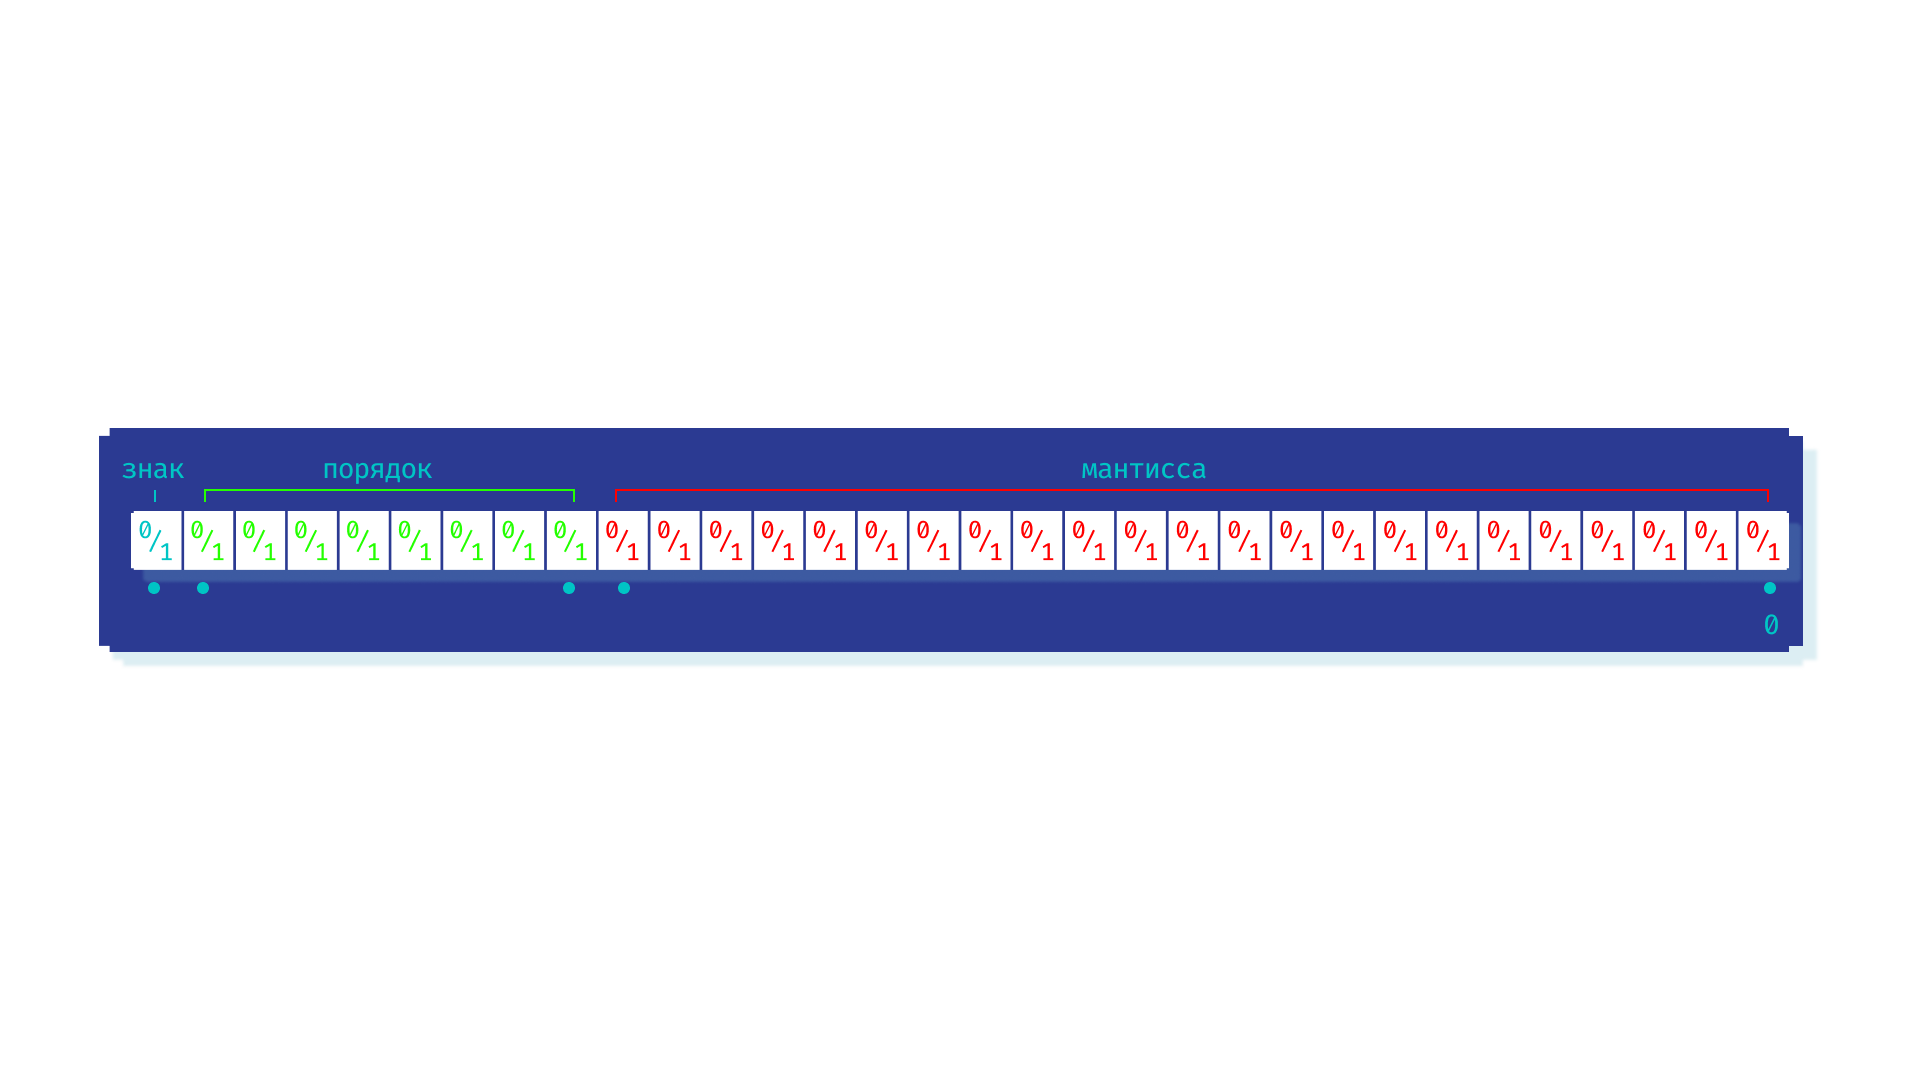

Математически это записывается следующим образом:

$(-1) ^ s × M × B^E$, где $s$ - знак, $B$ - основание, $E$ - порядок, а $M$ - мантисса.

Основание определяет систему счисления разрядов. Математически доказано, что числа с плавающей запятой с базой $B = 2$ (двоичное представление) наиболее устойчивы к ошибкам округления, поэтому на практике встречаются только базы $2$ и реже $10$. Для дальнейшего изложения будем всегда полагать $B = 2$, и формула числа с плавающей запятой будет иметь вид:

$(-1) ^ s × M × 2^E$

### Ошибки сложения при разных порядках чисел

In [ ]:
1000000000000000. + 1

1000000000000001.0

In [ ]:
x = 10000000000000000.
print(x)
for i in range(10000000):
    x += 1.
print(x)
print(1000000000000000. + 1. * 10000000)

1e+16
1e+16
1000000010000000.0


In [ ]:
10000000000000000. + 10000000

1.000000001e+16

In [ ]:
10000000000000000.  + 3

1.0000000000000004e+16

### Недопустимость сравнения `==` (на равенство) для чисел `float`

Числа типа `float`, полученные как результат вычислений, не стоит сравнивать друг с другом без учёта погрешностей вычислений и погрешности представления.

Например, такие дроби, как 0.1, 0.2 и 0.3, в двоичном представлении являются бесконечными периодическими дробями, а значит:

In [ ]:
if 0.1 + 0.2 == 0.3:
    print("С математикой всё нормально!")
else:
    print("Что за безобразие?..")

Что за безобразие?..


### Виды округлений

Перевод дробных чисел в целые может осуществляться по-разному. Рассмотрим что делает стандартный `int()`, изобразив результат на графике:

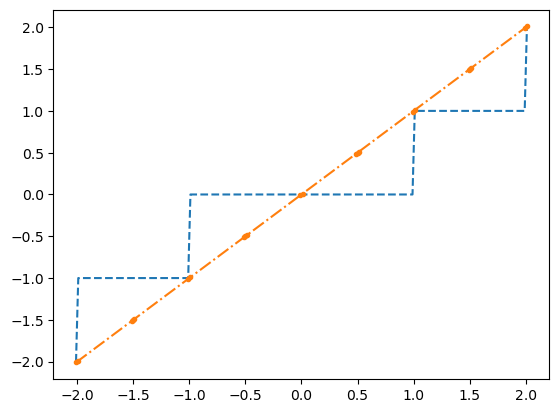

-2.01	--->	-2
-1.99	--->	-1
-1.51	--->	-1
-1.5	--->	-1
-1.49	--->	-1
-1.01	--->	-1
-0.99	--->	0
-0.51	--->	0
-0.5	--->	0
-0.49	--->	0
-0.01	--->	0
0.01	--->	0
0.49	--->	0
0.5	--->	0
0.51	--->	0
0.99	--->	0
1.01	--->	1
1.49	--->	1
1.5	--->	1
1.51	--->	1
1.99	--->	1
2.01	--->	2


In [ ]:
import matplotlib.pyplot as plt

my_range = [-2.01, -1.99, -1.51, -1.5, -1.49, -1.01, -0.99, -0.51, -0.5, -0.49, -0.01,
            0.01, 0.49, 0.5, 0.51,  0.99, 1.01, 1.49, 1.5, 1.51, 1.99, 2.01]
int_values = [int(x) for x in my_range]
plt.plot(my_range, int_values, '--',
         my_range, my_range, '.-.')
plt.show()
for x, y in zip(my_range, int_values):
    print(x, '--->', y, sep='\t')

Функция `math.trunc(x)` с точки зрения округления делает то же, что `int(x)`:

In [ ]:
import math
for x in my_range:
    m = int(x)
    z = math.trunc(x)
    print(x, m, z, sep='\t')

-2.01	-2	-2
-1.99	-1	-1
-1.51	-1	-1
-1.5	-1	-1
-1.49	-1	-1
-1.01	-1	-1
-0.99	0	0
-0.51	0	0
-0.5	0	0
-0.49	0	0
-0.01	0	0
0.01	0	0
0.49	0	0
0.5	0	0
0.51	0	0
0.99	0	0
1.01	1	1
1.49	1	1
1.5	1	1
1.51	1	1
1.99	1	1
2.01	2	2


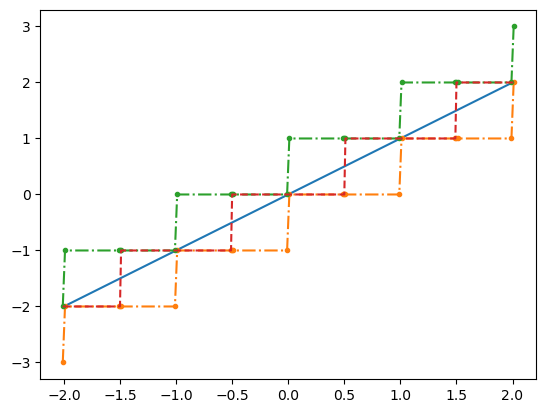

number		trunc	floor	ceil	round
-2.01	-->	-2     	-3     	-2     	-2     
-1.99	-->	-1     	-2     	-1     	-2     
-1.51	-->	-1     	-2     	-1     	-2     
-1.5	-->	-1     	-2     	-1     	-2     
-1.49	-->	-1     	-2     	-1     	-1     
-1.01	-->	-1     	-2     	-1     	-1     
-0.99	-->	0      	-1     	0      	-1     
-0.51	-->	0      	-1     	0      	-1     
-0.5	-->	0      	-1     	0      	0      
-0.49	-->	0      	-1     	0      	0      
-0.01	-->	0      	-1     	0      	0      
0.01	-->	0      	0      	1      	0      
0.49	-->	0      	0      	1      	0      
0.5 	-->	0      	0      	1      	0      
0.51	-->	0      	0      	1      	1      
0.99	-->	0      	0      	1      	1      
1.01	-->	1      	1      	2      	1      
1.49	-->	1      	1      	2      	1      
1.5 	-->	1      	1      	2      	2      
1.51	-->	1      	1      	2      	2      
1.99	-->	1      	1      	2      	2      
2.01	-->	2      	2      	3      	2      


In [ ]:
import math
import matplotlib.pyplot as plt

my_range = [-2.01, -1.99, -1.51, -1.5, -1.49, -1.01, -0.99, -0.51, -0.5, -0.49, -0.01,
            0.01, 0.49, 0.5, 0.51,  0.99, 1.01, 1.49, 1.5, 1.51, 1.99, 2.01]
floor_values = [math.floor(x) for x in my_range]
round_values = [round(x) for x in my_range]
ceil_values = [math.ceil(x) for x in my_range]

plt.plot(my_range, my_range, '-',
         my_range, floor_values, '.-.',
         my_range, ceil_values, '.-.',
         my_range, round_values, '--')
plt.show()
trunc_values = [math.trunc(x) for x in my_range]
print("number", "", "trunc", "floor", "ceil", "round", sep='\t')
for x, *values in zip(my_range, trunc_values, floor_values, ceil_values, round_values):
    print(str(x).ljust(4), '-->', *(str(x).ljust(7) for x in values), sep='\t')

### Тонкости округления функцией `round`

В школе вас учили, что при дробной части, равной ровно 0.5, число всегда округляется вверх.

То есть 0.5 должно округляться к единице, 1.5 — к двум, 2.5 — к трём и так далее...

In [ ]:
for x in 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5:
    print(f'round({x}) ==', round(x))

round(0.5) == 0
round(1.5) == 2
round(2.5) == 2
round(3.5) == 4
round(4.5) == 4
round(5.5) == 6
round(6.5) == 6


> "Забудьте то, чему вас учили в школе!" © *Вузовские преподаватели с высоким ЧСВ*

В данном случае Python лучше знает современную математику, чем вы...

Дело в том, что при реальных расчётах классический способ округления приводит к накоплению статистической ошибки вычислений.
Математики придумали несколько приёмов снижения этой ошибки, в том числе и случайное направление округления.
Но в Python заложен другой, *детерминированный* вариант, — *округление через одно число идёт в другом направлении*.

Побочный эффект: после округления число всегда получается чётным.